### Python Standard Library

In [28]:
import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns

### Download Dataset

In [29]:
!wget https://statistik.tu-dortmund.de/storages/statistik/r/Downloads/Studium/Studiengaenge-Infos/Data_Science/cycling.txt

--2025-12-03 10:55:16--  https://statistik.tu-dortmund.de/storages/statistik/r/Downloads/Studium/Studiengaenge-Infos/Data_Science/cycling.txt
Resolving statistik.tu-dortmund.de (statistik.tu-dortmund.de)... 129.217.143.204
Connecting to statistik.tu-dortmund.de (statistik.tu-dortmund.de)|129.217.143.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159939 (156K) [text/plain]
Saving to: ‘cycling.txt.1’

cycling.txt.1       100%[===================>] 156.19K   499KB/s    in 0.3s    

2025-12-03 10:55:18 (499 KB/s) - ‘cycling.txt.1’ saved [159939/159939]



## Load txt Dataset and convert it to csv

In [30]:
df = pd.read_csv('cycling.txt', sep=' ', quotechar='"')

In [31]:
print(df.head())

      all_riders  rider_class stage  points stage_class
0  Tadej Pogačar  All Rounder    X1      15        flat
1  Tadej Pogačar  All Rounder    X2     219       hills
2  Tadej Pogačar  All Rounder    X3      34        flat
3  Tadej Pogačar  All Rounder    X4     264       hills
4  Tadej Pogačar  All Rounder    X6     114       hills


## Load the csv format dataset

In [32]:
df.to_csv('cycling_data.csv', index=False)

In [33]:
df = pd.read_csv('cycling_data.csv')

print("DataFrame 'df' loaded successfully.")
print("Displaying the first 5 rows:")
print(df.head())

DataFrame 'df' loaded successfully.
Displaying the first 5 rows:
      all_riders  rider_class stage  points stage_class
0  Tadej Pogačar  All Rounder    X1      15        flat
1  Tadej Pogačar  All Rounder    X2     219       hills
2  Tadej Pogačar  All Rounder    X3      34        flat
3  Tadej Pogačar  All Rounder    X4     264       hills
4  Tadej Pogačar  All Rounder    X6     114       hills


In [34]:
num_rows, num_cols = df.shape

print(f"Dataset Size:")
print(f"Number of Rows (Observations): {num_rows:,}")
print(f"Number of Columns (Features): {num_cols}")

Dataset Size:
Number of Rows (Observations): 3,496
Number of Columns (Features): 5


Check for Missing Values

In [35]:
print("Missing values per column:")
print(df.isnull().sum())

print("\n" + "="*40)
print("Data types and non-null counts:")
df.info()

Missing values per column:
all_riders     0
rider_class    0
stage          0
points         0
stage_class    0
dtype: int64

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3496 entries, 0 to 3495
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   all_riders   3496 non-null   object
 1   rider_class  3496 non-null   object
 2   stage        3496 non-null   object
 3   points       3496 non-null   int64 
 4   stage_class  3496 non-null   object
dtypes: int64(1), object(4)
memory usage: 136.7+ KB


In [36]:
# 1. Calculate the counts for rider_class
rider_class_counts_df = df['rider_class'].value_counts().reset_index()

# 2. Rename columns for clean output
rider_class_counts_df.columns = ['Rider Class', 'Count']

# 3. Print the results in Markdown table format
print("--- Rider Class Counts ---")
print(rider_class_counts_df.to_markdown(index=False))

# 4. Calculate and print the total number of entries
total_entries = df['rider_class'].count()
print(f"\nTotal number of entries across all Rider Class categories: {total_entries}")

--- Rider Class Counts ---
| Rider Class   |   Count |
|:--------------|--------:|
| Unclassed     |    2185 |
| Sprinter      |     551 |
| Climber       |     437 |
| All Rounder   |     323 |

Total number of entries across all Rider Class categories: 3496


In [37]:
# Colab Code: Count Unique Stages

# Calculate the total number of unique stage identifiers (e.g., X1, X2, etc.)
unique_stage_count = df['stage'].nunique()

print(f"Total number of unique stages: {unique_stage_count}")

Total number of unique stages: 19


In [38]:
# Simple Colab Code: Count Stage Class Entries

# Calculate the frequency count of each stage_class
stage_class_counts = df['stage_class'].value_counts().reset_index()
stage_class_counts.columns = ['Stage Class', 'Count']

# Sort the stages alphabetically for consistent output
stage_class_counts = stage_class_counts.sort_values(by='Stage Class')

print(stage_class_counts.to_markdown(index=False))

| Stage Class   |   Count |
|:--------------|--------:|
| flat          |    1104 |
| hills         |    1472 |
| mount         |     920 |


In [39]:
# 1. Calculate the total points for each Rider Class.
total_points_by_class = df.groupby('rider_class')['points'].sum().reset_index()
total_points_by_class.columns = ['Rider Class', 'Total Points']

# 2. Sort the table to find the maximum scorer.
total_points_by_class = total_points_by_class.sort_values(by='Total Points', ascending=False)

# 3. Extract the top-scoring class.
max_scorer_class = total_points_by_class.iloc[0]

print("--- Rider Class with Maximum Total Points ---")
print(f"The Rider Class with the maximum points is: {max_scorer_class['Rider Class']}")
print(f"Total Points Scored: {max_scorer_class['Total Points']:,}\n")

print("--- Full Summary of Total Points by Class ---")
print(total_points_by_class.to_markdown(index=False))

--- Rider Class with Maximum Total Points ---
The Rider Class with the maximum points is: Unclassed
Total Points Scored: 14,027

--- Full Summary of Total Points by Class ---
| Rider Class   |   Total Points |
|:--------------|---------------:|
| Unclassed     |          14027 |
| All Rounder   |          12173 |
| Climber       |           8814 |
| Sprinter      |           8285 |


In [40]:
# Code to recreate the Average Points Matrix:
df.pivot_table(index='rider_class', columns='stage_class', values='points', aggfunc='mean').round(2)

stage_class,flat,hills,mount
rider_class,,,
All Rounder,15.44,35.79,67.42
Climber,5.09,21.67,35.86
Sprinter,38.98,5.20,2.04
Unclassed,5.74,9.10,2.95


In [41]:
df['rider_class'].value_counts()

,count
rider_class,
Unclassed,2185
Sprinter,551
Climber,437
All Rounder,323


In [42]:
df.groupby('rider_class')['points'].describe()

,count,mean,std,min,25%,50%,75%,max
rider_class,,,,,,,,
All Rounder,323.0,37.687307,63.961640,0.0,0.0,12.0,39.5,304.0
Climber,437.0,20.169336,43.447254,0.0,0.0,6.0,16.0,269.0
Sprinter,551.0,15.036298,41.832247,0.0,0.0,0.0,4.0,272.0
Unclassed,2185.0,6.419680,23.282527,0.0,0.0,0.0,2.0,260.0


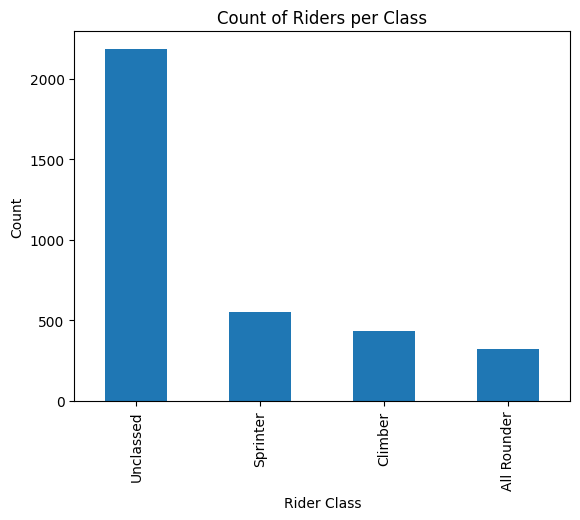

In [43]:
df['rider_class'].value_counts().plot(kind='bar')
plt.title("Count of Riders per Class")
plt.xlabel("Rider Class")
plt.ylabel("Count")
plt.show()

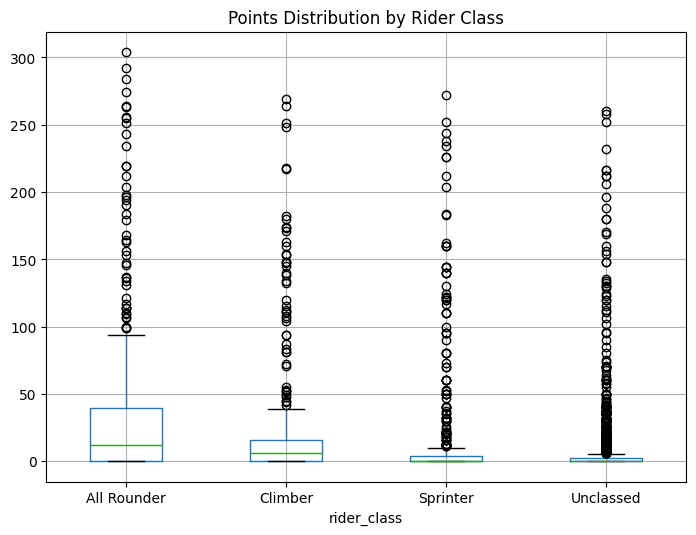

In [44]:
df.boxplot(column='points', by='rider_class', figsize=(8,6))
plt.title("Points Distribution by Rider Class")
plt.suptitle("")
plt.show()

In [45]:
performance_stats = df.groupby(['rider_class', 'stage_class'])['points'].agg(
    ['mean', 'median', 'std', 'min', 'max']
).round(2)

print("--- Detailed Descriptive Statistics of Points (Grouped) ---")
print(performance_stats.to_markdown())

--- Detailed Descriptive Statistics of Points (Grouped) ---
|                          |   mean |   median |   std |   min |   max |
|:-------------------------|-------:|---------:|------:|------:|------:|
| ('All Rounder', 'flat')  |  15.44 |      8   | 28.28 |     0 |   194 |
| ('All Rounder', 'hills') |  35.79 |     12.5 | 57.46 |     0 |   274 |
| ('All Rounder', 'mount') |  67.42 |     17   | 88.96 |     0 |   304 |
| ('Climber', 'flat')      |   5.09 |      1.5 |  6.23 |     0 |    26 |
| ('Climber', 'hills')     |  21.67 |      7   | 45.98 |     0 |   264 |
| ('Climber', 'mount')     |  35.86 |     12   | 57.02 |     0 |   269 |
| ('Sprinter', 'flat')     |  38.98 |      2.5 | 63.59 |     0 |   272 |
| ('Sprinter', 'hills')    |   5.2  |      0   | 21.95 |     0 |   244 |
| ('Sprinter', 'mount')    |   2.04 |      0   |  5.89 |     0 |    32 |
| ('Unclassed', 'flat')    |   5.74 |      0   | 19.8  |     0 |   232 |
| ('Unclassed', 'hills')   |   9.1  |      0   | 30.66 |     0 |

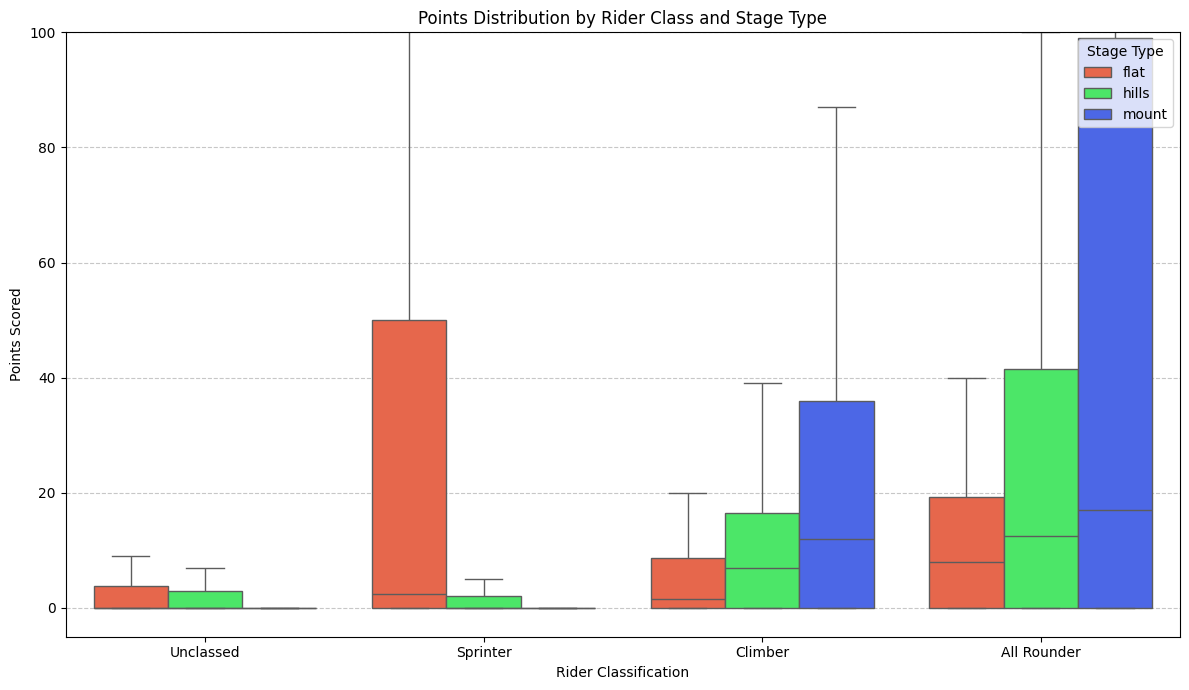

In [46]:
# Colab Code: Grouped Box Plot for Performance Comparison

import matplotlib.pyplot as plt
import seaborn as sns

# Create the grouped box plot to show points distribution for each class across stage types.
plt.figure(figsize=(12, 7))
sns.boxplot(
    x='rider_class',
    y='points',
    hue='stage_class',
    data=df,
    # Custom colors for stage types
    palette={'flat': '#FF5733', 'hills': '#33FF57', 'mount': '#3357FF'},
    # Maintain the order based on overall size (Unclassed, Sprinter, Climber, All Rounder)
    order=df['rider_class'].value_counts().index,
    showfliers=False # Hides extreme outliers to focus on the core distribution
)

plt.title('Points Distribution by Rider Class and Stage Type')
plt.ylabel('Points Scored')
plt.xlabel('Rider Classification')
plt.ylim(-5, 100) # Limiting Y-axis to focus on central tendency and IQR
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Stage Type', loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

/tmp/ipython-input-3905596915.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


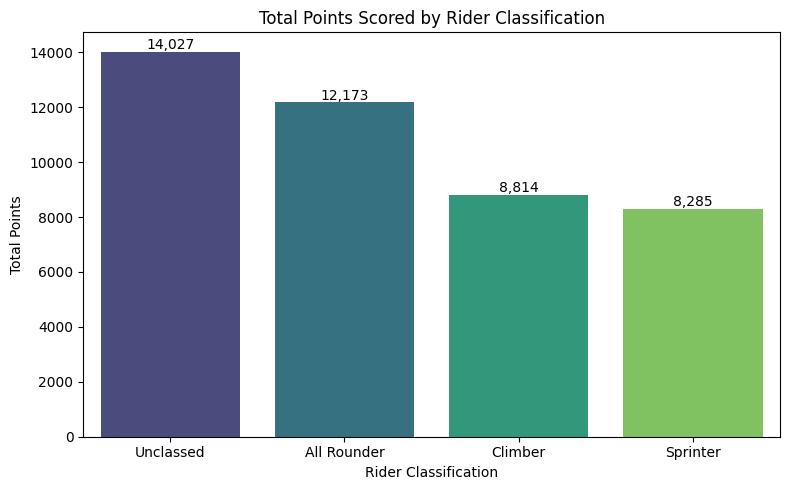

In [47]:
# Simple Colab Code: Bar Chart of Total Points by Rider Class

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Calculate the Total Points per Rider Class
total_points_by_class = df.groupby('rider_class')['points'].sum().sort_values(ascending=False).reset_index()
total_points_by_class.columns = ['Rider Class', 'Total Points']

# 2. Generate the visualization (Bar Chart)
plt.figure(figsize=(8, 5))
sns.barplot(
    x='Rider Class',
    y='Total Points',
    data=total_points_by_class,
    palette='viridis'
)

# Add data labels
for index, row in total_points_by_class.iterrows():
    plt.text(
        index,
        row['Total Points'] + 100,
        f"{row['Total Points']:,}",
        color='black',
        ha="center",
        fontsize=10
    )

plt.title('Total Points Scored by Rider Classification')
plt.ylabel('Total Points')
plt.xlabel('Rider Classification')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

/tmp/ipython-input-3583120172.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_5_df['Cumulative Points'] = top_5_df.groupby('all_riders')['points'].cumsum()
/tmp/ipython-input-3583120172.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_5_df['Stage Number'] = top_5_df['stage'].str.replace('X', '').astype(int)


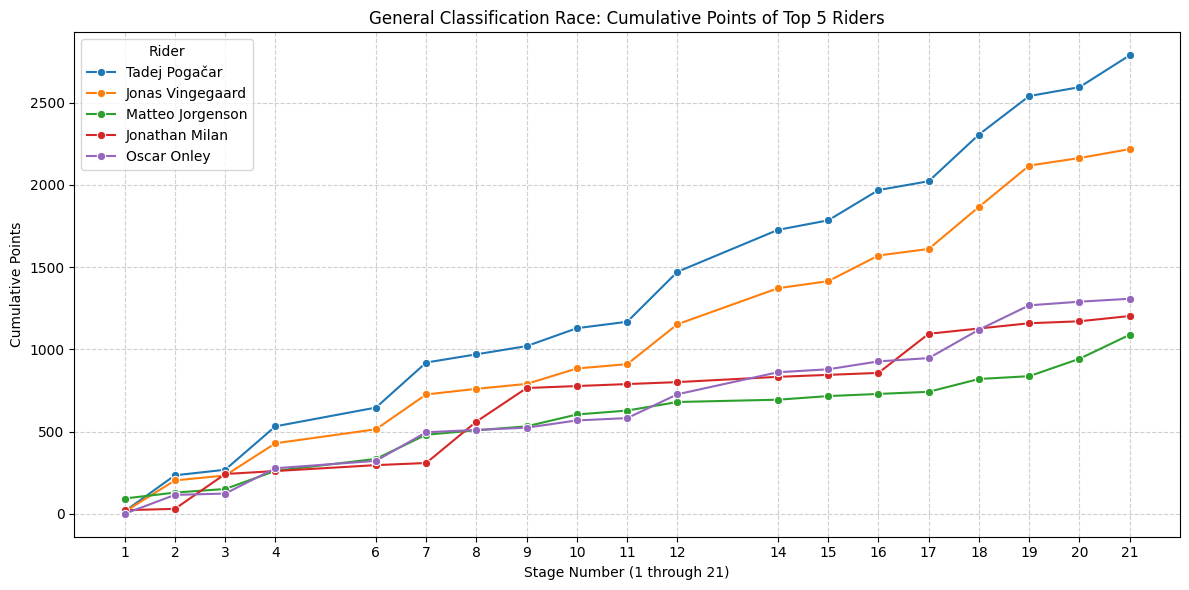

In [48]:
# Colab Code: Line Plot of Cumulative Points

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Identify the Top 5 Riders by Total Points
top_5_names = df.groupby('all_riders')['points'].sum().nlargest(5).index.tolist()
top_5_df = df[df['all_riders'].isin(top_5_names)]

# 2. Calculate the Cumulative Sum of Points for each of the Top 5 riders
#    The cumulative sum is calculated within each rider group.
top_5_df['Cumulative Points'] = top_5_df.groupby('all_riders')['points'].cumsum()

# 3. Ensure 'stage' is treated numerically (for sorting on the X-axis)
#    We will extract the number from 'X1', 'X2', etc.
top_5_df['Stage Number'] = top_5_df['stage'].str.replace('X', '').astype(int)
top_5_df = top_5_df.sort_values('Stage Number')

# 4. Generate the visualization (Line Plot)
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=top_5_df,
    x='Stage Number',
    y='Cumulative Points',
    hue='all_riders',
    marker='o',
    dashes=False
)

plt.title('General Classification Race: Cumulative Points of Top 5 Riders')
plt.ylabel('Cumulative Points')
plt.xlabel('Stage Number (1 through 21)')
plt.xticks(top_5_df['Stage Number'].unique())
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Rider', loc='upper left')
plt.tight_layout()

plt.show()

In [49]:
# CODE A.2: Descriptive Analysis Table

import pandas as pd

# Load the CSV generated in previous steps
df = pd.read_csv('cycling_data.csv')

# Calculate mean, median, standard deviation, minimum, and maximum points
# grouped by the combined factors.
descriptive_stats_table = df.groupby(['rider_class', 'stage_class'])['points'].agg(
    ['mean', 'median', 'std', 'min', 'max']
).round(2)

print("--- Descriptive Statistics of Points (Grouped) ---")
print(descriptive_stats_table.to_markdown())

--- Descriptive Statistics of Points (Grouped) ---
|                          |   mean |   median |   std |   min |   max |
|:-------------------------|-------:|---------:|------:|------:|------:|
| ('All Rounder', 'flat')  |  15.44 |      8   | 28.28 |     0 |   194 |
| ('All Rounder', 'hills') |  35.79 |     12.5 | 57.46 |     0 |   274 |
| ('All Rounder', 'mount') |  67.42 |     17   | 88.96 |     0 |   304 |
| ('Climber', 'flat')      |   5.09 |      1.5 |  6.23 |     0 |    26 |
| ('Climber', 'hills')     |  21.67 |      7   | 45.98 |     0 |   264 |
| ('Climber', 'mount')     |  35.86 |     12   | 57.02 |     0 |   269 |
| ('Sprinter', 'flat')     |  38.98 |      2.5 | 63.59 |     0 |   272 |
| ('Sprinter', 'hills')    |   5.2  |      0   | 21.95 |     0 |   244 |
| ('Sprinter', 'mount')    |   2.04 |      0   |  5.89 |     0 |    32 |
| ('Unclassed', 'flat')    |   5.74 |      0   | 19.8  |     0 |   232 |
| ('Unclassed', 'hills')   |   9.1  |      0   | 30.66 |     0 |   260 |


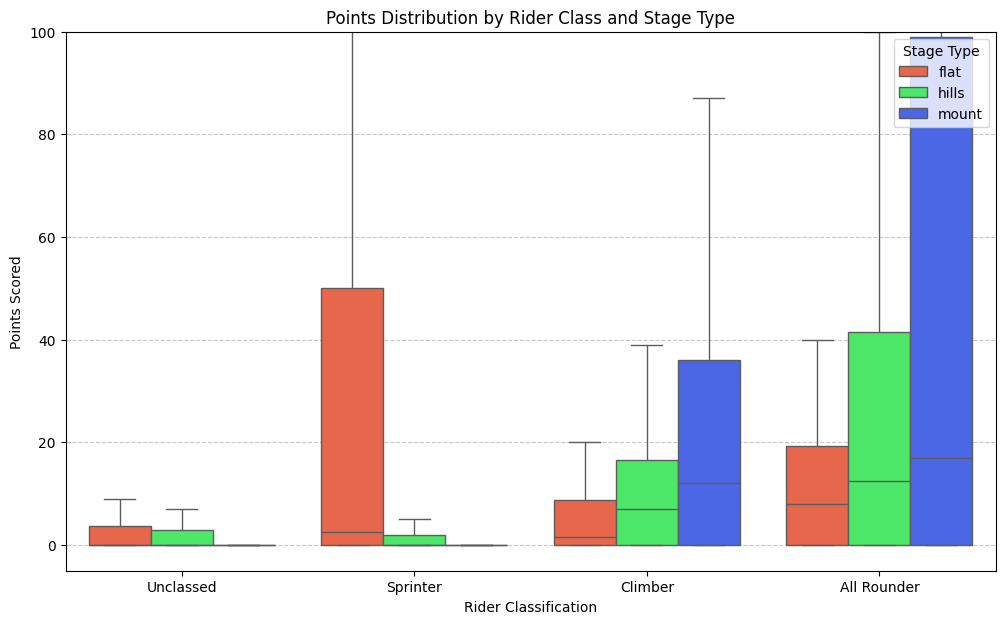

In [50]:
# CODE A.3: Statistical Graphic - Grouped Box Plot

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.boxplot(
    x='rider_class',
    y='points',
    hue='stage_class',
    data=df,
    palette={'flat': '#FF5733', 'hills': '#33FF57', 'mount': '#3357FF'},
    order=df['rider_class'].value_counts().index,
    showfliers=False # Focus on central tendency (IQR)
)

plt.title('Points Distribution by Rider Class and Stage Type')
plt.ylabel('Points Scored')
plt.xlabel('Rider Classification')
plt.ylim(-5, 100) # Setting Y-limit to compare medians effectively
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Stage Type', loc='upper right')
plt.show()

In [51]:
# CODE B.2: Kruskal-Wallis H-Test for Mountain Stages

from scipy import stats

# Define the Hypotheses
print("H0: The median points scored are the same across all rider classes on MOUNT stages.")
print("HA: At least one rider class has a different median score on MOUNT stages.")

# 1. Prepare data (filter for 'mount' stages)
mount_data = df[df['stage_class'] == 'mount']

# 2. Create list of groups (points scores for each rider class)
groups_to_test = [mount_data[mount_data['rider_class'] == c]['points']
                  for c in mount_data['rider_class'].unique()]

# 3. Run the test
h_statistic, p_value = stats.kruskal(*groups_to_test)

# 4. Print Results
print("\n--- Kruskal-Wallis Test Results (Mountain Stages) ---")
print(f"H-Statistic: {h_statistic:.2f}")
print(f"P-Value: {p_value:.5f}")

if p_value < 0.05:
    print("\nConclusion: Reject H0. There is a statistically significant difference in median scores between rider classes on Mountain Stages.")
else:
    print("\nConclusion: Fail to reject H0.")

H0: The median points scored are the same across all rider classes on MOUNT stages.
HA: At least one rider class has a different median score on MOUNT stages.

--- Kruskal-Wallis Test Results (Mountain Stages) ---
H-Statistic: 183.16
P-Value: 0.00000

Conclusion: Reject H0. There is a statistically significant difference in median scores between rider classes on Mountain Stages.


In [52]:
# CODE B.3: Kruskal-Wallis H-Test for Flat Stages

from scipy import stats

# Define the Hypotheses
print("H0: The median points scored are the same across all rider classes on FLAT stages.")
print("HA: At least one rider class has a different median score on FLAT stages.")

# 1. Prepare data (filter for 'flat' stages)
flat_data = df[df['stage_class'] == 'flat']

# 2. Create list of groups (points scores for each rider class)
groups_to_test = [flat_data[flat_data['rider_class'] == c]['points']
                  for c in flat_data['rider_class'].unique()]

# 3. Run the test
h_statistic, p_value = stats.kruskal(*groups_to_test)

# 4. Print Results
print("\n--- Kruskal-Wallis Test Results (Flat Stages) ---")
print(f"H-Statistic: {h_statistic:.2f}")
print(f"P-Value: {p_value:.5f}")

if p_value < 0.05:
    print("\nConclusion: Reject H0. There is a statistically significant difference in median scores between rider classes on Flat Stages.")
else:
    print("\nConclusion: Fail to reject H0.")

H0: The median points scored are the same across all rider classes on FLAT stages.
HA: At least one rider class has a different median score on FLAT stages.

--- Kruskal-Wallis Test Results (Flat Stages) ---
H-Statistic: 82.10
P-Value: 0.00000

Conclusion: Reject H0. There is a statistically significant difference in median scores between rider classes on Flat Stages.


In [53]:
# Colab Code: Independent Two-Sample T-Test

from scipy import stats
import pandas as pd # Ensure pandas is imported if running this cell alone

print("--- Two-Sample Independent T-Test (Parametric Test) ---")
print("Comparing: All Rounder performance vs. Climber performance on MOUNT stages.")
print("NOTE: This test assumes normal data distribution and equal variances (which may be violated in this dataset).")

# 1. Define groups for comparison: Scores for each class on MOUNT stages
all_rounder_mount_scores = df[(df['rider_class'] == 'All Rounder') & (df['stage_class'] == 'mount')]['points']
climber_mount_scores = df[(df['rider_class'] == 'Climber') & (df['stage_class'] == 'mount')]['points']

# 2. Check the mean difference observed in the sample
print(f"\nMean Score (All Rounder, Mount): {all_rounder_mount_scores.mean():.2f}")
print(f"Mean Score (Climber, Mount): {climber_mount_scores.mean():.2f}")


# 3. Run the Independent Samples T-Test
# Null Hypothesis (H0): The true mean scores are equal (Mean_AR = Mean_Climber).
t_statistic, p_value = stats.ttest_ind(
    a=all_rounder_mount_scores,
    b=climber_mount_scores,
    equal_var=True # Assuming equal variances for this example
)

# 4. Print Results
print("\nTEST RESULTS:")
print(f"T-Statistic: {t_statistic:.3f}")
print(f"P-Value: {p_value:.5f}")

print("\nInterpretation (using alpha=0.05):")
print("If P-Value < 0.05, the difference in the means is statistically significant.")

--- Two-Sample Independent T-Test (Parametric Test) ---
Comparing: All Rounder performance vs. Climber performance on MOUNT stages.
NOTE: This test assumes normal data distribution and equal variances (which may be violated in this dataset).

Mean Score (All Rounder, Mount): 67.42
Mean Score (Climber, Mount): 35.86

TEST RESULTS:
T-Statistic: 3.051
P-Value: 0.00259

Interpretation (using alpha=0.05):
If P-Value < 0.05, the difference in the means is statistically significant.


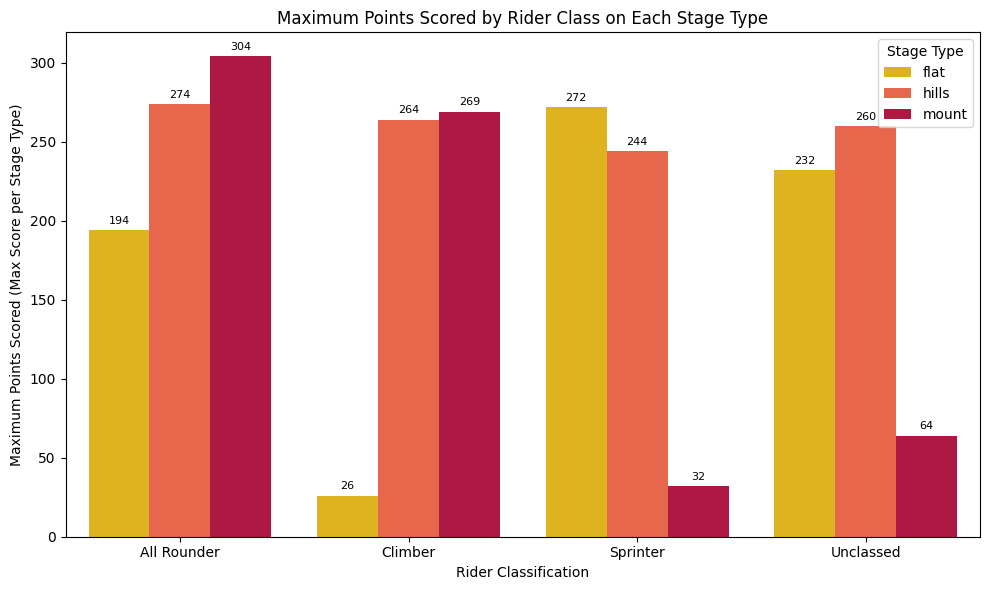

In [54]:
# Colab Code: Grouped Bar Chart of Maximum Points

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Calculate the Maximum Points scored by each group
max_scores_by_group = df.groupby(['rider_class', 'stage_class'])['points'].max().reset_index()
max_scores_by_group.columns = ['Rider Class', 'Stage Class', 'Max Points']

# 2. Generate the grouped bar plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Rider Class',
    y='Max Points',
    hue='Stage Class',
    data=max_scores_by_group,
    palette={'flat': '#FFC300', 'hills': '#FF5733', 'mount': '#C70039'}
)

# Add data labels (Max Score values)
for container in plt.gca().containers:
    plt.bar_label(container, fmt='%d', padding=3, fontsize=8)

plt.title('Maximum Points Scored by Rider Class on Each Stage Type')
plt.ylabel('Maximum Points Scored (Max Score per Stage Type)')
plt.xlabel('Rider Classification')
plt.xticks(rotation=0)
plt.legend(title='Stage Type', loc='upper right')
plt.tight_layout()

plt.show()

/tmp/ipython-input-2157473625.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


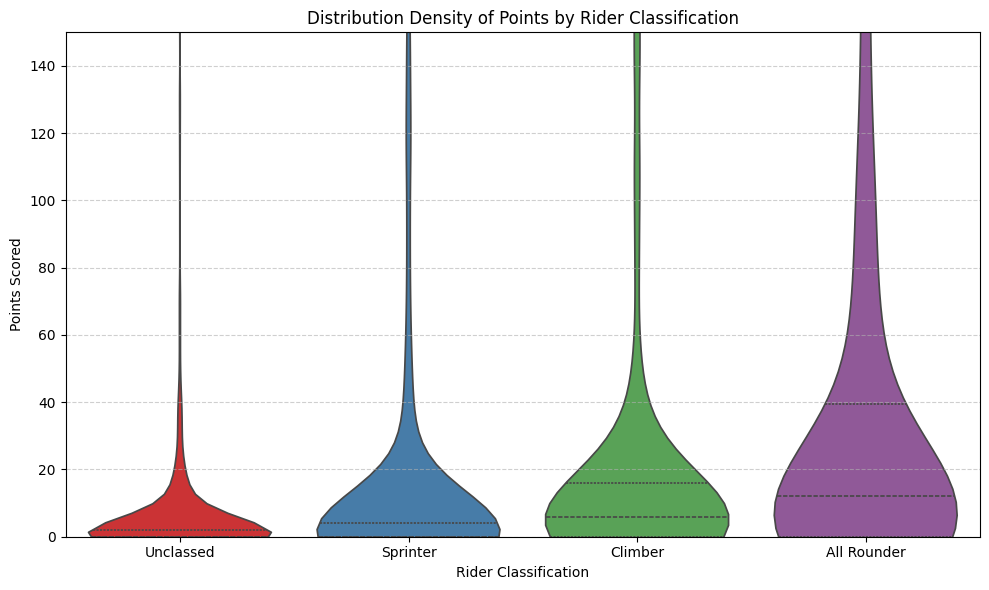

In [55]:
# Colab Code: Violin Plot of Points Distribution by Rider Class

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Set up the visualization
plt.figure(figsize=(10, 6))

# 2. Generate the Violin Plot
sns.violinplot(
    x='rider_class',
    y='points',
    data=df,
    inner='quartile',  # Shows quartiles (like a mini box plot inside the violin)
    palette='Set1',
    # Order by frequency (Unclassed, Sprinter, Climber, All Rounder)
    order=df['rider_class'].value_counts().index
)

plt.title('Distribution Density of Points by Rider Classification')
plt.ylabel('Points Scored')
plt.xlabel('Rider Classification')
# Limit Y-axis to focus on the main body of density below the extreme outliers
plt.ylim(0, 150)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

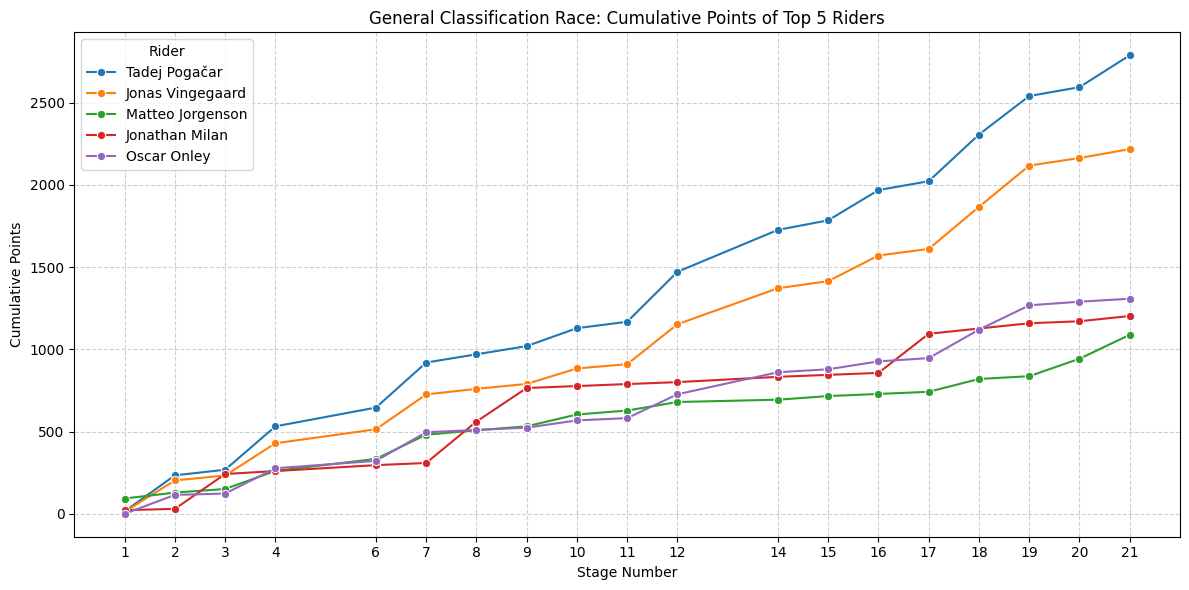

In [56]:
# Colab Code: Line Plot of Cumulative Points

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Identify the Top 5 Riders by Total Points
# Identify the top 5 riders based on total score across all stages
top_5_names = df.groupby('all_riders')['points'].sum().nlargest(5).index.tolist()
top_5_df = df[df['all_riders'].isin(top_5_names)].copy()

# 2. Prepare the X-axis (Stage Number)
# Convert 'X1', 'X2', etc., to numerical stage identifiers (1, 2, 3...)
top_5_df['Stage Number'] = top_5_df['stage'].str.replace('X', '').astype(int)
top_5_df = top_5_df.sort_values('Stage Number')

# 3. Calculate the Cumulative Sum of Points (General Classification progression)
# Use transform/cumsum to calculate the running total for each rider independently
top_5_df['Cumulative Points'] = top_5_df.groupby('all_riders')['points'].cumsum()

# 4. Generate the visualization (Line Plot)
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=top_5_df,
    x='Stage Number',
    y='Cumulative Points',
    hue='all_riders',
    marker='o',
    dashes=False
)

plt.title('General Classification Race: Cumulative Points of Top 5 Riders')
plt.ylabel('Cumulative Points')
plt.xlabel('Stage Number')
plt.xticks(top_5_df['Stage Number'].unique())
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Rider', loc='upper left')
plt.tight_layout()

plt.show()

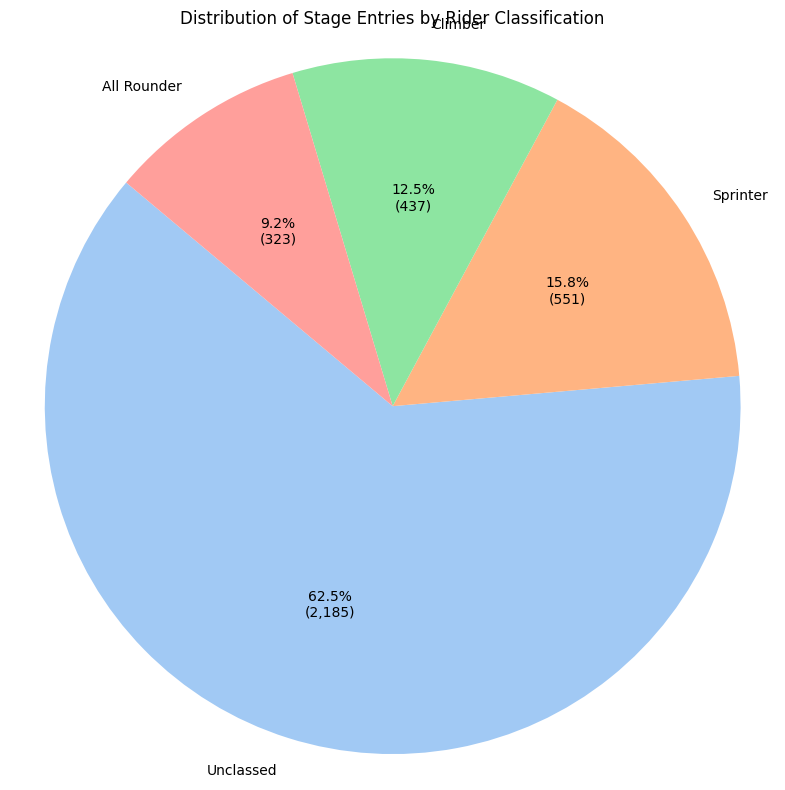

In [57]:
# Colab Code: Pie Chart for Rider Classification Distribution

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Calculate the total count of entries for each Rider Class
# This represents the dataset composition based on classification frequency.
rider_class_counts = df['rider_class'].value_counts()

# 2. Set up the visualization
plt.figure(figsize=(8, 8))

# 3. Generate the Pie Chart
plt.pie(
    rider_class_counts,
    labels=rider_class_counts.index,
    # Custom formatting function to show both percentage and raw count
    autopct=lambda p: '{:.1f}%\n({:,.0f})'.format(p, p * sum(rider_class_counts) / 100),
    startangle=140,
    colors=sns.color_palette('pastel')
)

plt.title('Distribution of Stage Entries by Rider Classification')
plt.axis('equal') # Ensures the pie is drawn as a perfect circle
plt.tight_layout()

plt.show()

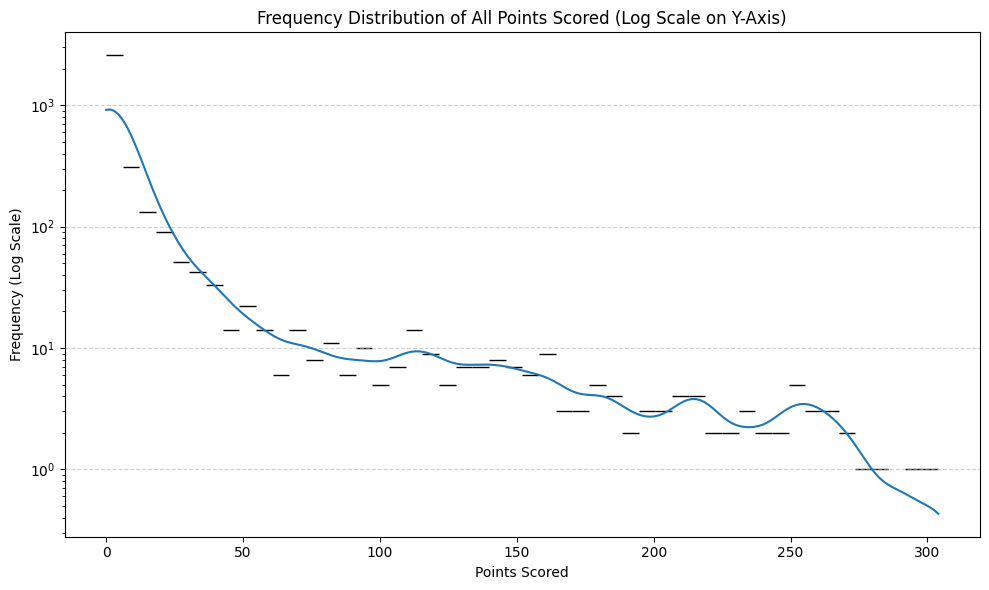

In [58]:
# Colab Code: Histogram of Points Distribution

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plt.figure(figsize=(10, 6))

# Generate the Histogram
sns.histplot(
    data=df,
    x='points',
    bins=50, # Number of bins (intervals) for grouping the scores
    kde=True, # Adds a smooth Kernel Density Estimate curve
    log_scale=(False, True) # IMPORTANT: Uses log scale on the Y-axis to handle the extreme frequency of zero scores
)

plt.title('Frequency Distribution of All Points Scored (Log Scale on Y-Axis)')
plt.ylabel('Frequency (Log Scale)')
plt.xlabel('Points Scored')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

plt.show()

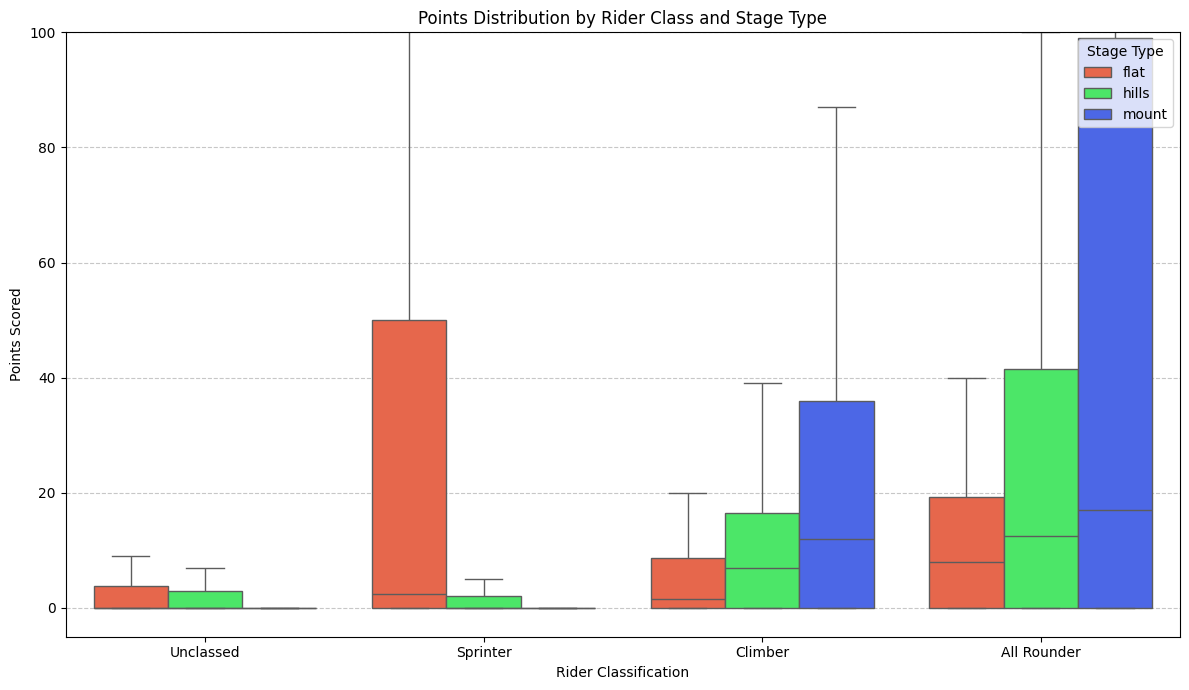

In [59]:
# Colab Code: Grouped Box Plot for Performance Comparison

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create the grouped box plot to show points distribution for each class across stage types.
plt.figure(figsize=(12, 7))
sns.boxplot(
    x='rider_class',
    y='points',
    hue='stage_class',
    data=df,
    # Custom colors for stage types
    palette={'flat': '#FF5733', 'hills': '#33FF57', 'mount': '#3357FF'},
    # Maintain the order based on overall size/preference
    order=df['rider_class'].value_counts().index,
    showfliers=False # Hides extreme outliers to focus on the IQR and median
)

plt.title('Points Distribution by Rider Class and Stage Type')
plt.ylabel('Points Scored')
plt.xlabel('Rider Classification')
plt.ylim(-5, 100) # Limiting Y-axis to focus on central tendency and IQR
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Stage Type', loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

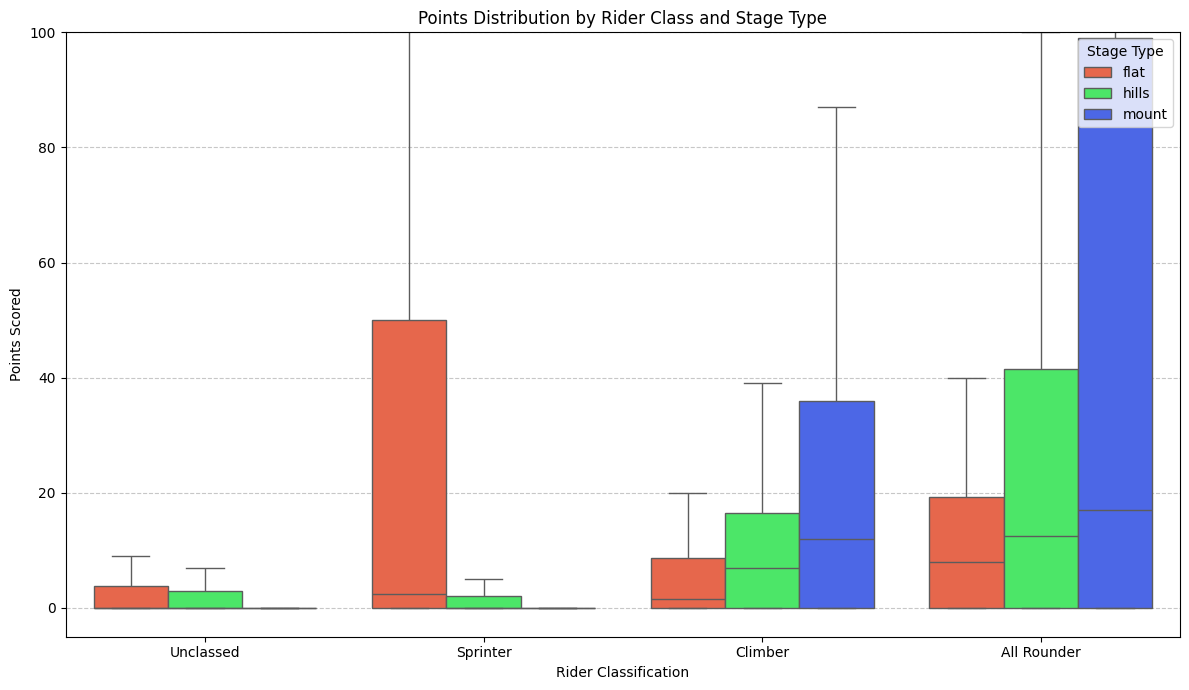

In [60]:
# Colab Code: Grouped Box Plot for Performance Comparison

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create the grouped box plot to show points distribution for each class across stage types.
plt.figure(figsize=(12, 7))
sns.boxplot(
    x='rider_class',
    y='points',
    hue='stage_class',
    data=df,
    # Custom colors for stage types
    palette={'flat': '#FF5733', 'hills': '#33FF57', 'mount': '#3357FF'},
    # Maintain the order based on overall size/preference
    order=df['rider_class'].value_counts().index,
    showfliers=False # Hides extreme outliers (scores > 100) to focus on the IQR and median
)

plt.title('Points Distribution by Rider Class and Stage Type')
plt.ylabel('Points Scored')
plt.xlabel('Rider Classification')
plt.ylim(-5, 100) # Limiting Y-axis to focus on central tendency and IQR
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Stage Type', loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

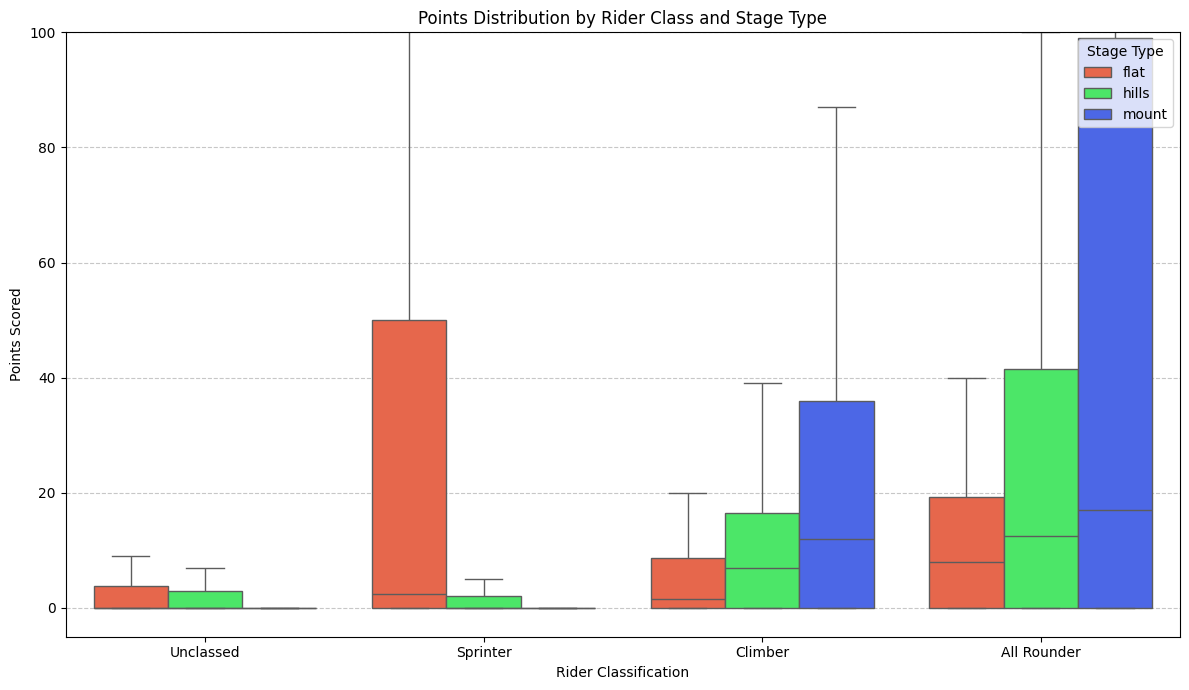

In [61]:
# Colab Code: Grouped Box Plot for Performance Comparison

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create the grouped box plot to show points distribution for each class across stage types.
plt.figure(figsize=(12, 7))
sns.boxplot(
    x='rider_class',
    y='points',
    hue='stage_class',
    data=df,
    # Custom colors for stage types
    palette={'flat': '#FF5733', 'hills': '#33FF57', 'mount': '#3357FF'},
    # Maintain the order based on overall size/preference
    order=df['rider_class'].value_counts().index,
    showfliers=False # Hides extreme outliers (scores > 100) to focus on the IQR and median
)

plt.title('Points Distribution by Rider Class and Stage Type')
plt.ylabel('Points Scored')
plt.xlabel('Rider Classification')
plt.ylim(-5, 100) # Limiting Y-axis to focus on central tendency and IQR
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Stage Type', loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()